# **Import || Preprocessing || EDA**

In [ ]:
# STEP 0: Mount Google Drive & Load Dataset
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np

file_path = "/content/drive/MyDrive/ObesityDataSet_raw_and_data_sinthetic.csv"
df = pd.read_csv(file_path)
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


(2111, 17)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   object 
 12  FAF                    

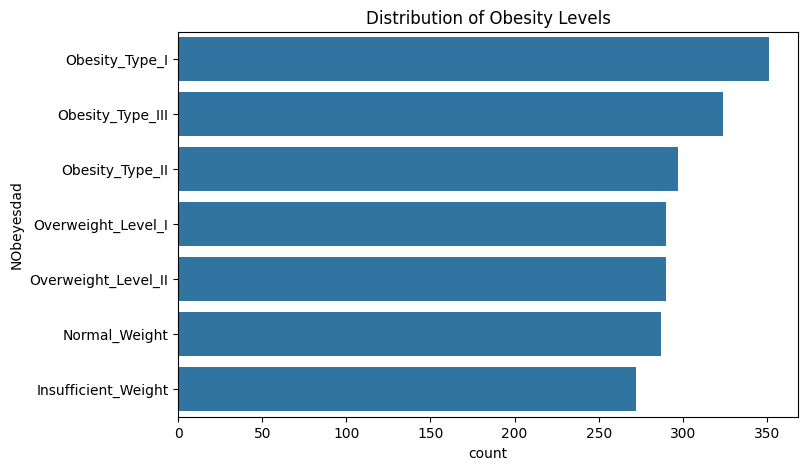

In [ ]:
# Basic info
print(df.shape)
print(df.info())
print(df['NObeyesdad'].value_counts())

import matplotlib.pyplot as plt
import seaborn as sns

# Figure 1: Class Distribution
plt.figure(figsize=(8,5))
sns.countplot(y=df['NObeyesdad'], order=df['NObeyesdad'].value_counts().index)
plt.title("Distribution of Obesity Levels")
plt.show()

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['NObeyesdad'] = le.fit_transform(df['NObeyesdad'])

categorical_cols = df.select_dtypes(include=['object']).columns
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

df_encoded.head()

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE,NObeyesdad,Gender_Male,...,CAEC_no,SMOKE_yes,SCC_yes,CALC_Frequently,CALC_Sometimes,CALC_no,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking
0,21.0,1.62,64.0,2.0,3.0,2.0,0.0,1.0,1,False,...,False,False,False,False,False,True,False,False,True,False
1,21.0,1.52,56.0,3.0,3.0,3.0,3.0,0.0,1,False,...,False,True,True,False,True,False,False,False,True,False
2,23.0,1.80,77.0,2.0,3.0,2.0,2.0,1.0,1,True,...,False,False,False,True,False,False,False,False,True,False
3,27.0,1.80,87.0,3.0,3.0,2.0,2.0,0.0,5,True,...,False,False,False,True,False,False,False,False,False,True
4,22.0,1.78,89.8,2.0,1.0,2.0,0.0,0.0,6,True,...,False,False,False,False,True,False,False,False,True,False


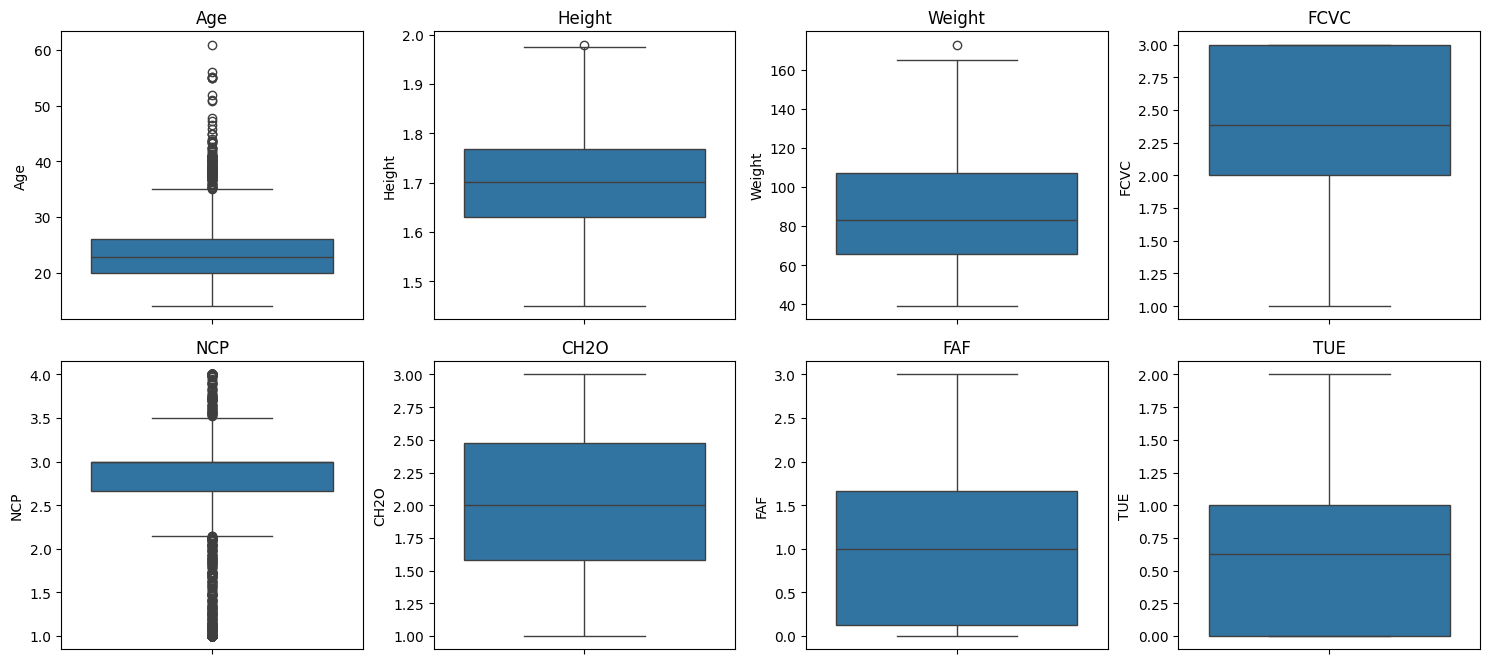

In [ ]:
num_cols = df_encoded.select_dtypes(include=['int64','float64']).columns.tolist()
num_cols.remove('NObeyesdad')

plt.figure(figsize=(15,10))
for i, col in enumerate(num_cols):
    plt.subplot(3,4,i+1)
    sns.boxplot(df_encoded[col])
    plt.title(col)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler

X = df_encoded.drop('NObeyesdad', axis=1)
y = df_encoded['NObeyesdad']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=42
)

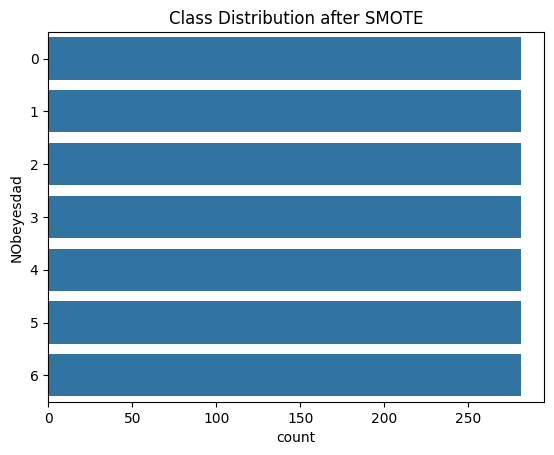

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

# Class distribution after SMOTE
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(y=y_train_sm)
plt.title("Class Distribution after SMOTE")
plt.show()

# **Model Implimentation**

In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 8.2 MB/s eta 0:00:00


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# Logistic Regression
lr = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=2000)
lr_params = {'C':[0.01,0.1,1,10]}

# Random Forest
rf = RandomForestClassifier(random_state=42)
rf_params = {'n_estimators':[100,200], 'max_depth':[None,10,20], 'min_samples_split':[2,5]}

# XGBoost
xgb = XGBClassifier(objective='multi:softprob', num_class=7, eval_metric='mlogloss', random_state=42)
xgb_params = {'n_estimators':[100,200], 'max_depth':[3,6], 'learning_rate':[0.05,0.1], 'subsample':[0.8,1.0]}

# LightGBM
lgb = LGBMClassifier(objective='multiclass', random_state=42)
lgb_params = {'n_estimators':[100,200], 'learning_rate':[0.05,0.1], 'num_leaves':[31,50]}

# CatBoost
cat = CatBoostClassifier(loss_function='MultiClass', verbose=0, random_state=42)
cat_params = {'depth':[6,8], 'learning_rate':[0.05,0.1], 'iterations':[200,300]}

# SVM
svm = SVC(probability=True)
svm_params = {'C':[0.1,1,10], 'kernel':['rbf','linear']}

# Combine
models_params = {
    "Logistic Regression": (lr, lr_params),
    "Random Forest": (rf, rf_params),
    "XGBoost": (xgb, xgb_params),
    "LightGBM": (lgb, lgb_params),
    "CatBoost": (cat, cat_params),
    "SVM": (svm, svm_params)
}

best_models = {}

In [ ]:
for name, (model, params) in models_params.items():
    print(f"\nRunning GridSearchCV for {name}...")
    grid = GridSearchCV(estimator=model, param_grid=params, cv=5, scoring='f1_weighted', n_jobs=-1)
    grid.fit(X_train_sm, y_train_sm)
    best_models[name] = grid.best_estimator_
    print(f"Best Parameters for {name}: {grid.best_params_}")


Running GridSearchCV for Logistic Regression...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Best Parameters for Logistic Regression: {'C': 10}

Running GridSearchCV for Random Forest...
Best Parameters for Random Forest: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}

Running GridSearchCV for XGBoost...
Best Parameters for XGBoost: {'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 200, 'subsample': 0.8}

Running GridSearchCV for LightGBM...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000307 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2117
[LightGBM] [Info] Number of data points in the train set: 1967, number of used features: 21
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best Parameters for CatBoost: {'depth': 6, 'iterations': 300, 'learning_rate': 0.1}

Running GridSearchCV for SVM...
Best Parameters for SVM: {'C': 10, 'kernel': 'linear'}


MODEL: Logistic Regression
Accuracy: 0.9267139479905437

Classification Report:
                     precision    recall  f1-score   support

Insufficient_Weight       0.95      1.00      0.97        54
      Normal_Weight       0.86      0.83      0.84        58
     Obesity_Type_I       0.94      0.94      0.94        70
    Obesity_Type_II       0.95      0.97      0.96        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       0.84      0.84      0.84        58
Overweight_Level_II       0.93      0.91      0.92        58

           accuracy                           0.93       423
          macro avg       0.92      0.93      0.93       423
       weighted avg       0.93      0.93      0.93       423



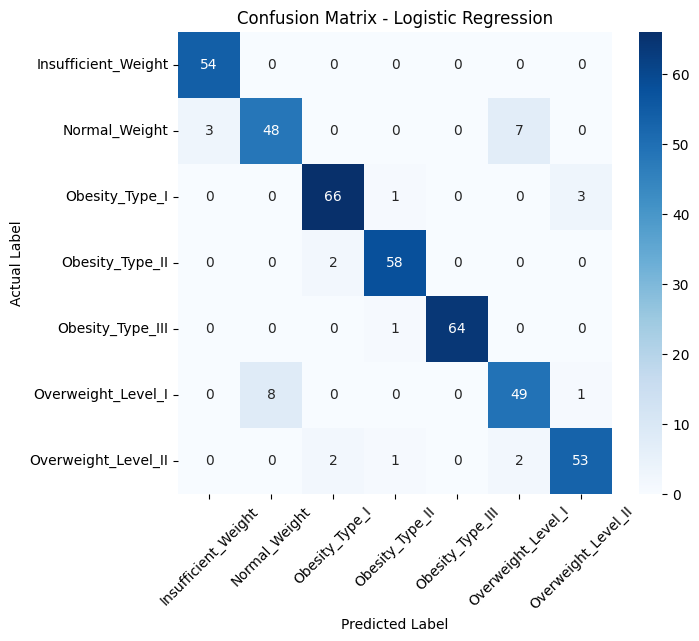

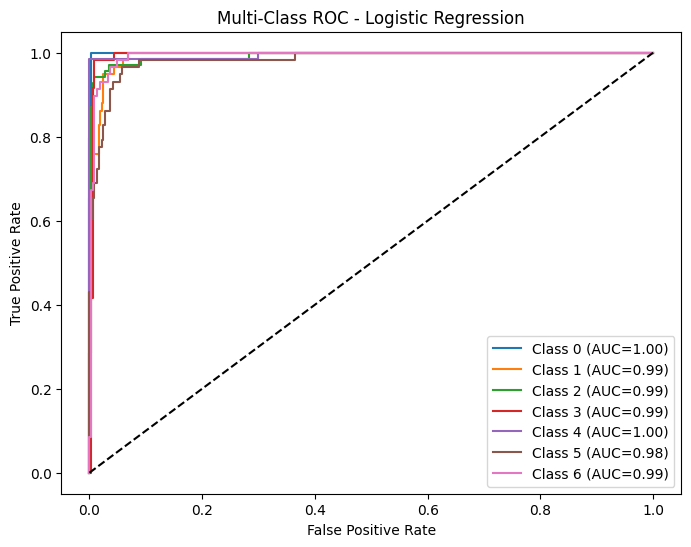

MODEL: Random Forest
Accuracy: 0.9456264775413712

Classification Report:
                     precision    recall  f1-score   support

Insufficient_Weight       1.00      0.93      0.96        54
      Normal_Weight       0.79      0.95      0.86        58
     Obesity_Type_I       0.96      0.97      0.96        70
    Obesity_Type_II       1.00      0.98      0.99        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       0.94      0.86      0.90        58
Overweight_Level_II       0.96      0.93      0.95        58

           accuracy                           0.95       423
          macro avg       0.95      0.94      0.95       423
       weighted avg       0.95      0.95      0.95       423



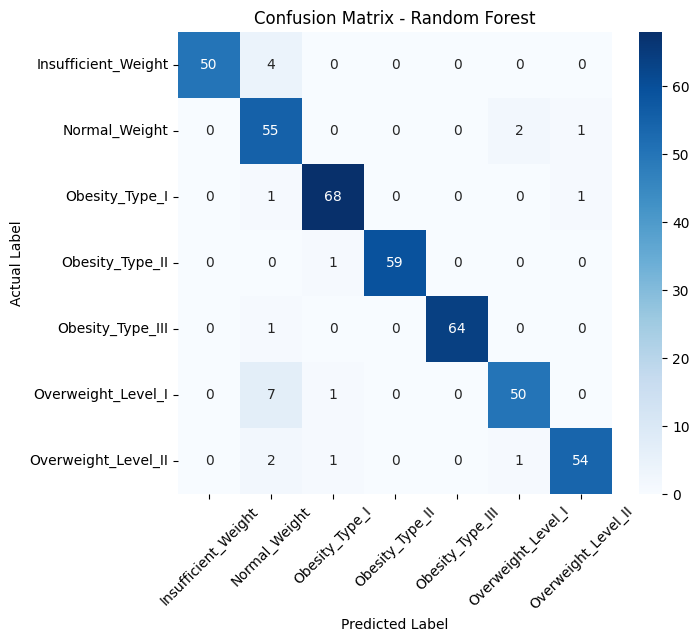

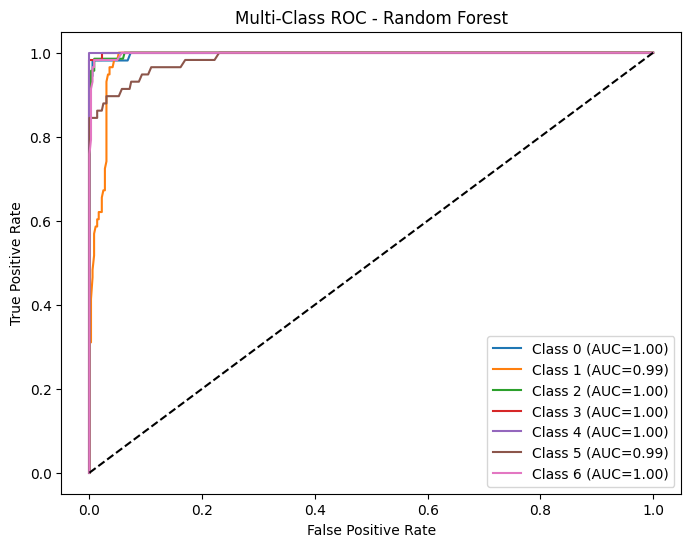

MODEL: XGBoost
Accuracy: 0.9527186761229315

Classification Report:
                     precision    recall  f1-score   support

Insufficient_Weight       0.98      0.93      0.95        54
      Normal_Weight       0.84      0.97      0.90        58
     Obesity_Type_I       0.97      0.96      0.96        70
    Obesity_Type_II       0.98      0.98      0.98        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       0.93      0.88      0.90        58
Overweight_Level_II       0.98      0.97      0.97        58

           accuracy                           0.95       423
          macro avg       0.95      0.95      0.95       423
       weighted avg       0.96      0.95      0.95       423



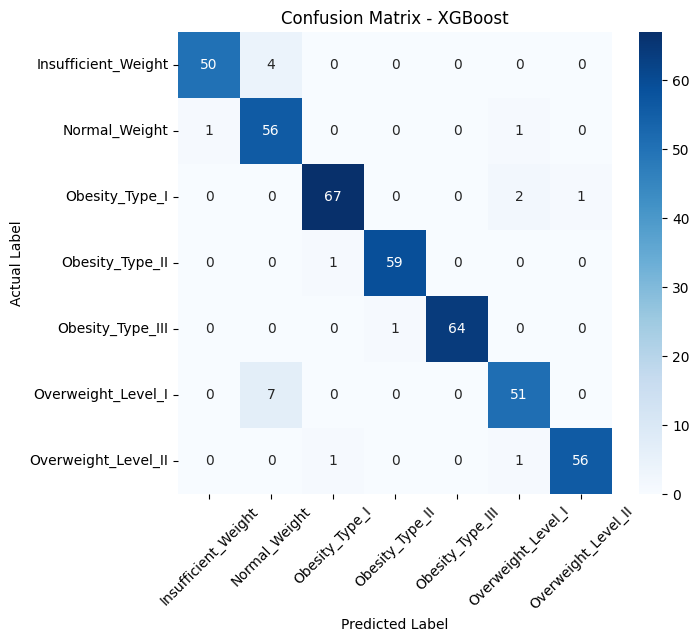

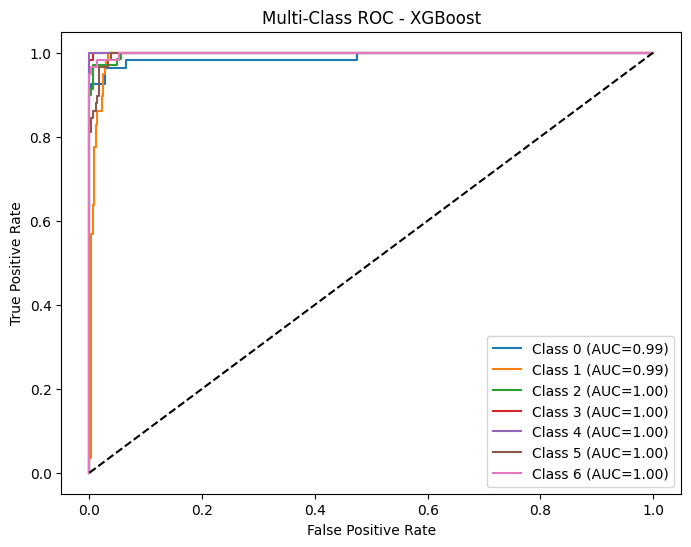

MODEL: LightGBM
Accuracy: 0.9621749408983451

Classification Report:
                     precision    recall  f1-score   support

Insufficient_Weight       0.96      0.93      0.94        54
      Normal_Weight       0.86      0.97      0.91        58
     Obesity_Type_I       0.99      0.96      0.97        70
    Obesity_Type_II       0.98      0.98      0.98        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       0.98      0.91      0.95        58
Overweight_Level_II       0.97      1.00      0.98        58

           accuracy                           0.96       423
          macro avg       0.96      0.96      0.96       423
       weighted avg       0.96      0.96      0.96       423



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


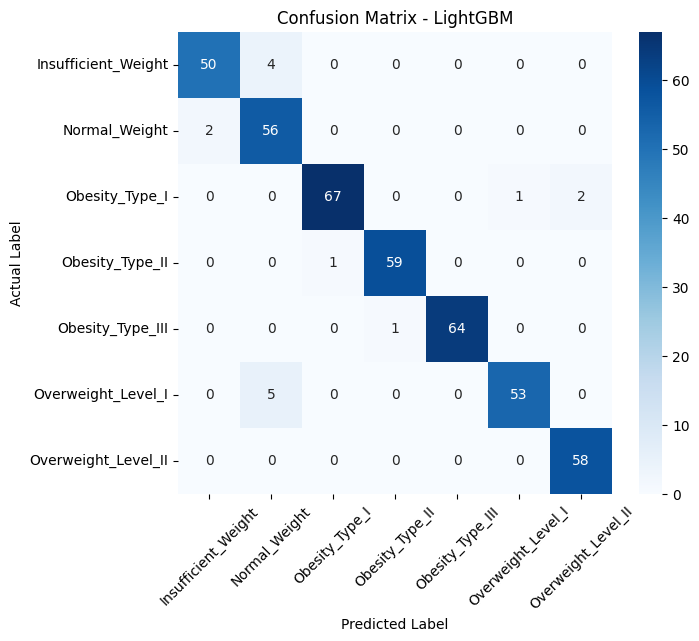

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


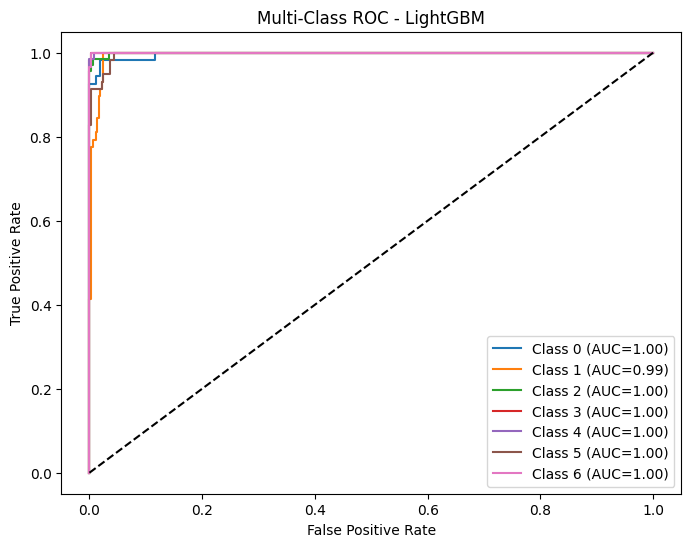

MODEL: CatBoost
Accuracy: 0.9574468085106383

Classification Report:
                     precision    recall  f1-score   support

Insufficient_Weight       1.00      0.93      0.96        54
      Normal_Weight       0.85      0.97      0.90        58
     Obesity_Type_I       0.99      0.97      0.98        70
    Obesity_Type_II       0.98      0.98      0.98        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       0.93      0.88      0.90        58
Overweight_Level_II       0.97      0.98      0.97        58

           accuracy                           0.96       423
          macro avg       0.96      0.96      0.96       423
       weighted avg       0.96      0.96      0.96       423



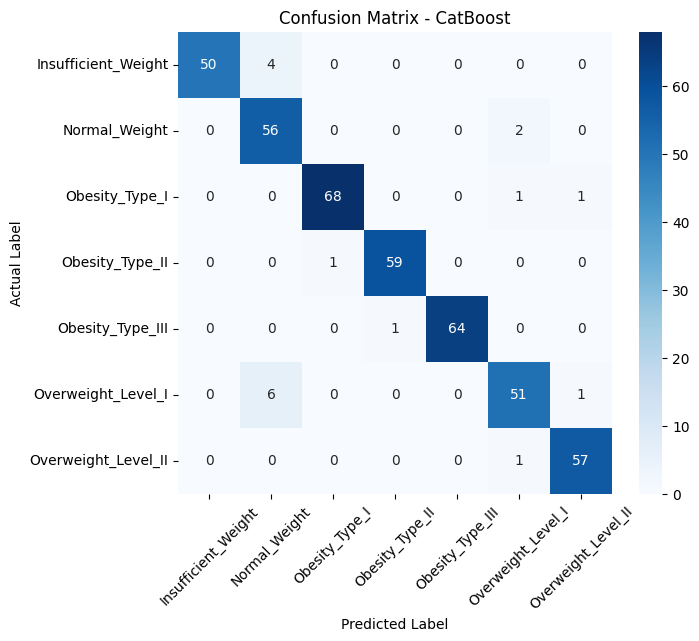

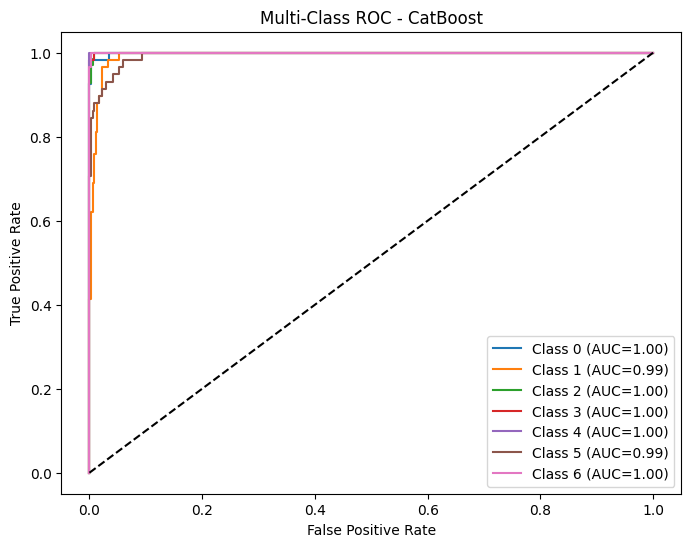

MODEL: SVM
Accuracy: 0.9621749408983451

Classification Report:
                     precision    recall  f1-score   support

Insufficient_Weight       0.96      1.00      0.98        54
      Normal_Weight       0.96      0.91      0.94        58
     Obesity_Type_I       0.97      0.96      0.96        70
    Obesity_Type_II       0.97      1.00      0.98        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       0.92      0.95      0.93        58
Overweight_Level_II       0.95      0.93      0.94        58

           accuracy                           0.96       423
          macro avg       0.96      0.96      0.96       423
       weighted avg       0.96      0.96      0.96       423



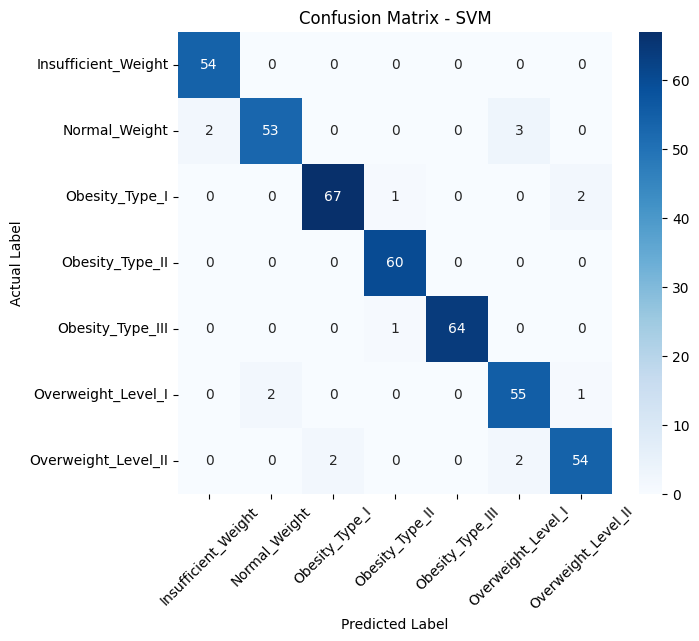

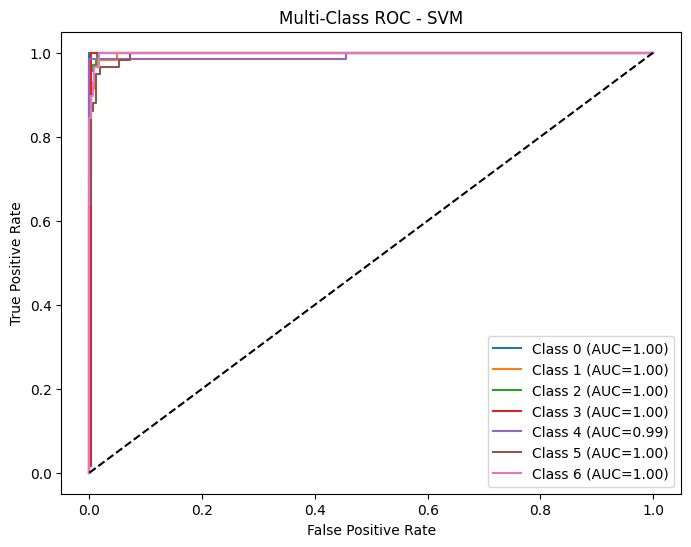

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score
from sklearn.preprocessing import label_binarize

# Binarize y for ROC-AUC
y_test_bin = label_binarize(y_test, classes=list(range(len(le.classes_))))

for name, model in best_models.items():
    print("="*70)
    print(f"MODEL: {name}")
    print("="*70)

    y_pred = model.predict(X_test)
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=le.classes_))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(7,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted Label")
    plt.ylabel("Actual Label")
    plt.xticks(rotation=45)
    plt.show()

    # ROC-AUC
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)
        from sklearn.metrics import roc_curve, auc
        plt.figure(figsize=(8,6))
        for i in range(y_test_bin.shape[1]):
            fpr, tpr, _ = roc_curve(y_test_bin[:,i], y_score[:,i])
            roc_auc = auc(fpr, tpr)
            plt.plot(fpr, tpr, label=f'Class {i} (AUC={roc_auc:.2f})')
        plt.plot([0,1],[0,1],'k--')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f'Multi-Class ROC - {name}')
        plt.legend()
        plt.show()

# **Explainable AI**

**Feature Importance + SHAP (Explainable AI)**

Shape of X_test: (423, 23)
Shape of X_test[0,:]: (23,)
Type of shap_values: numpy array with shape (423, 23, 7)
Shape of shap_values[0, :, 0]: (23,)
Length of X.columns: 23


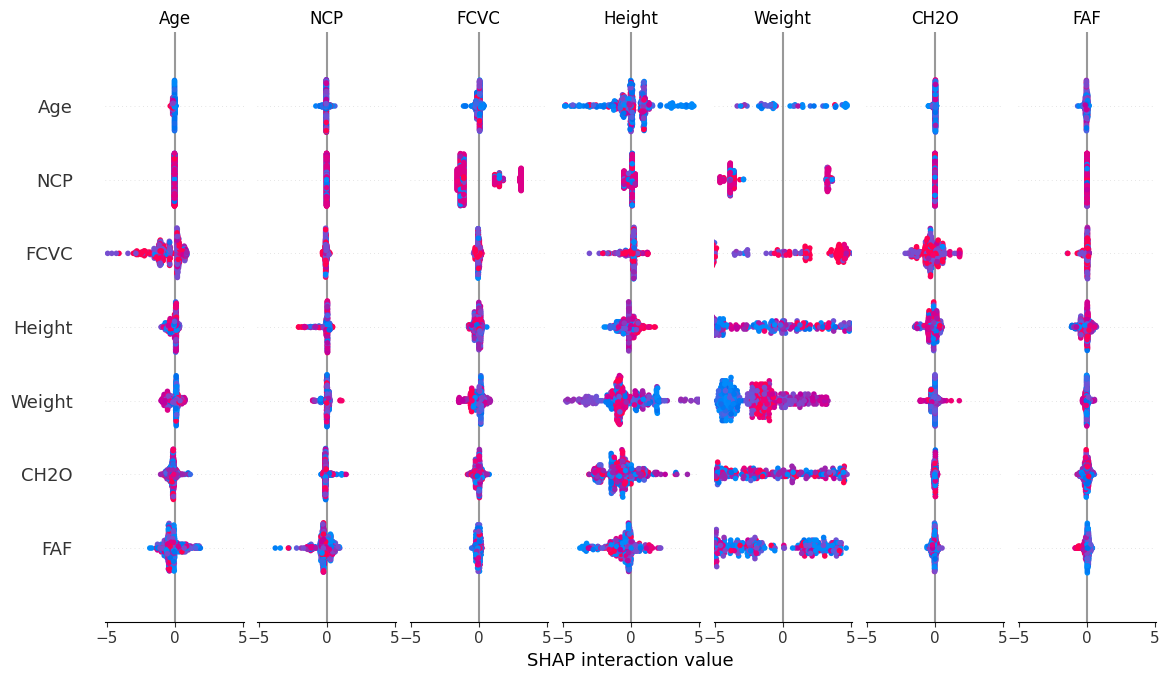

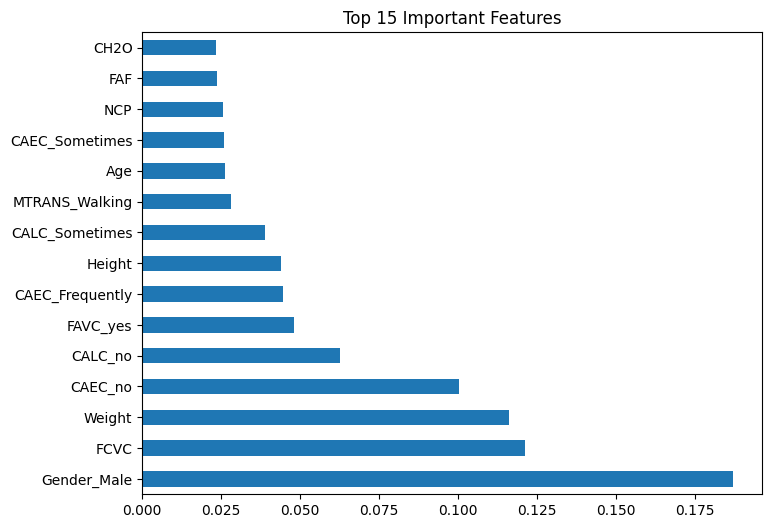

In [ ]:
import shap
import matplotlib.pyplot as plt
import pandas as pd # Ensure pandas is imported for Series

# Use tree-based model (e.g., XGBoost) for SHAP
explainer = shap.TreeExplainer(best_models['XGBoost'])
shap_values = explainer.shap_values(X_test)

# Debugging prints to check dimensions
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of X_test[0,:]: {X_test[0,:].shape}")

if isinstance(shap_values, list):
    print(f"Type of shap_values: list with {len(shap_values)} elements")
    if len(shap_values) > 0:
        print(f"Shape of shap_values[0]: {shap_values[0].shape}")
        if shap_values[0].shape[0] > 0:
            print(f"Shape of shap_values[0][0,:]: {shap_values[0][0,:].shape}")

else:
    print(f"Type of shap_values: numpy array with shape {shap_values.shape}")
    if shap_values.shape[0] > 0 and shap_values.shape[1] > 0 and shap_values.shape[2] > 0:
        print(f"Shape of shap_values[0, :, 0]: {shap_values[0, :, 0].shape}")
print(f"Length of X.columns: {len(X.columns)}")

# Global Explanation
shap.summary_plot(shap_values, X_test, feature_names=X.columns, class_names=le.classes_)

# Feature Importance Bar Plot
importances = best_models['XGBoost'].feature_importances_
feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=False)[:15]
plt.figure(figsize=(8,6))
feat_imp.plot(kind='barh')
plt.title("Top 15 Important Features")
plt.show()

shap.force_plot(explainer.expected_value[0], shap_values[0, :, 0], X_test[0,:], feature_names=X.columns)

**Save Final Results & Best Model**

In [ ]:
import joblib

# Save best XGBoost model
joblib.dump(best_models['XGBoost'], '/content/drive/MyDrive/Obesity_XGBoost_best_model.pkl')

# Save predictions & test set for paper figures
results_df = pd.DataFrame(X_test, columns=X.columns)
results_df['Actual'] = y_test
results_df['Predicted'] = best_models['XGBoost'].predict(X_test)
results_df.to_csv('/content/drive/MyDrive/Obesity_Results.csv', index=False)

**Figures**

/tmp/ipython-input-3226188807.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df['NObeyesdad'], order=df['NObeyesdad'].value_counts().index, palette="viridis")


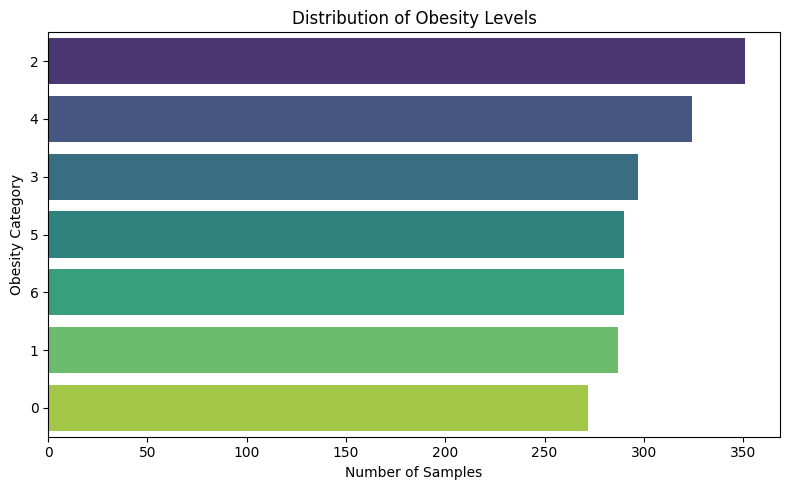

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(y=df['NObeyesdad'], order=df['NObeyesdad'].value_counts().index, palette="viridis")
plt.title("Distribution of Obesity Levels")
plt.xlabel("Number of Samples")
plt.ylabel("Obesity Category")
plt.tight_layout()
plt.show()

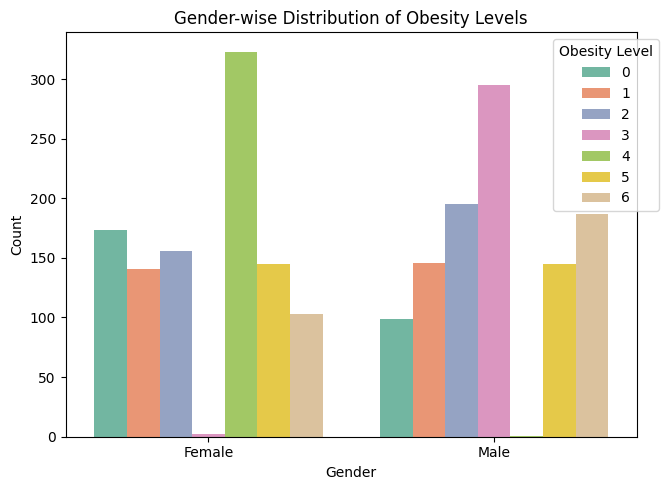

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Gender', hue='NObeyesdad', palette="Set2")
plt.title("Gender-wise Distribution of Obesity Levels")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.legend(title="Obesity Level", bbox_to_anchor=(1.05,1))
plt.tight_layout()
plt.show()

/tmp/ipython-input-146512815.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='NObeyesdad', y='Age', palette="Set3")


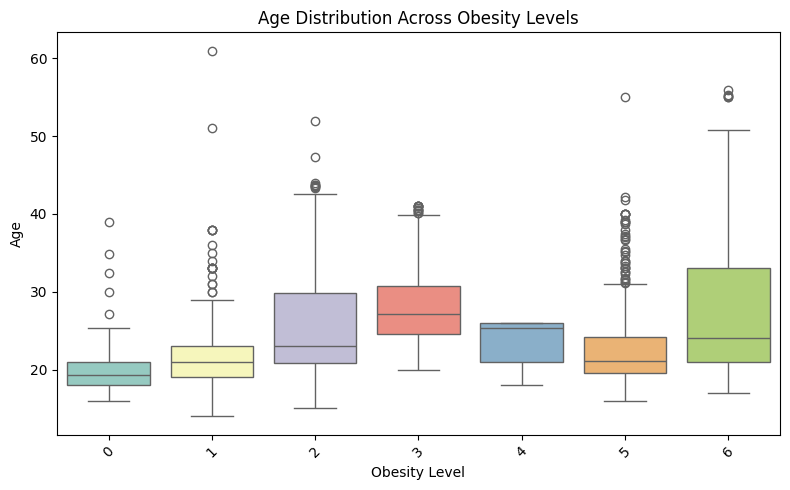

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='NObeyesdad', y='Age', palette="Set3")
plt.title("Age Distribution Across Obesity Levels")
plt.xlabel("Obesity Level")
plt.ylabel("Age")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/tmp/ipython-input-1888949749.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='NObeyesdad', y='Weight', palette="coolwarm")


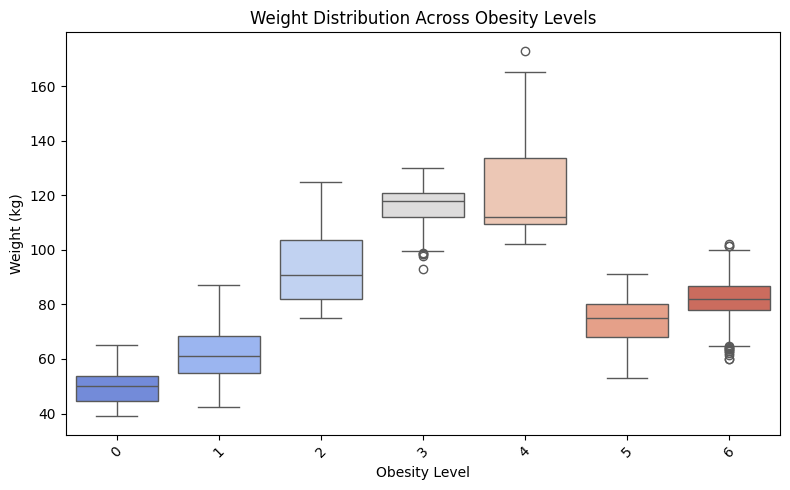

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='NObeyesdad', y='Weight', palette="coolwarm")
plt.title("Weight Distribution Across Obesity Levels")
plt.xlabel("Obesity Level")
plt.ylabel("Weight (kg)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/tmp/ipython-input-4037444860.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='NObeyesdad', y='BMI', palette="magma")


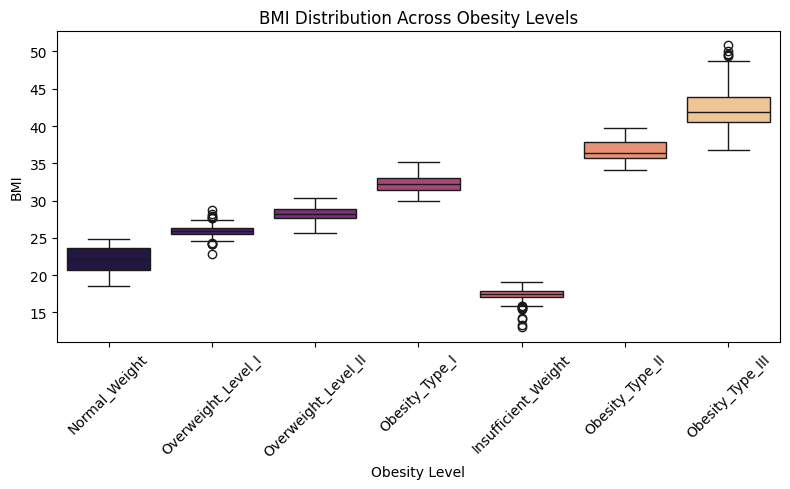

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='NObeyesdad', y='BMI', palette="magma")
plt.title("BMI Distribution Across Obesity Levels")
plt.xlabel("Obesity Level")
plt.ylabel("BMI")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

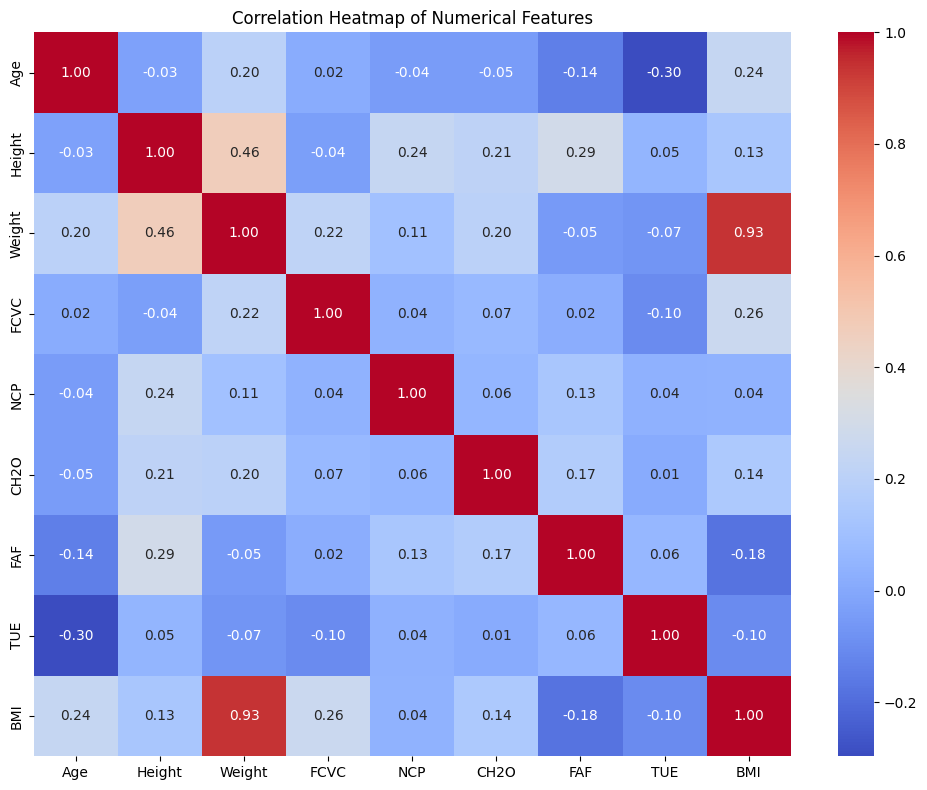

In [ ]:
plt.figure(figsize=(10,8))
num_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()

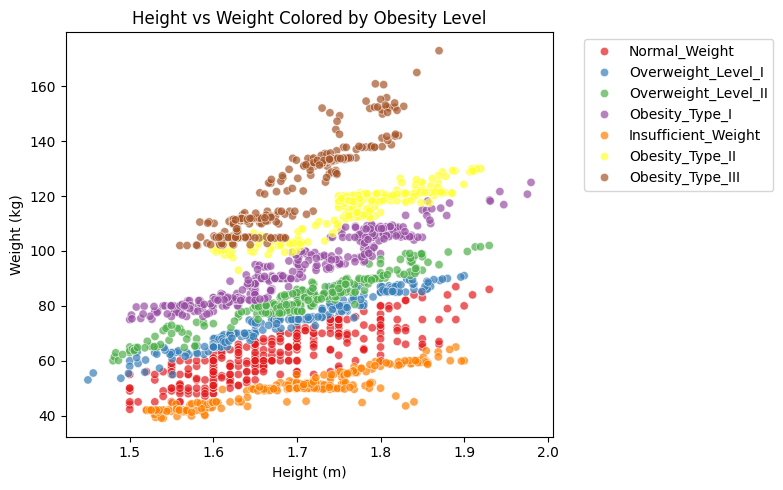

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='Height', y='Weight', hue='NObeyesdad', palette='Set1', alpha=0.7)
plt.title("Height vs Weight Colored by Obesity Level")
plt.xlabel("Height (m)")
plt.ylabel("Weight (kg)")
plt.legend(bbox_to_anchor=(1.05,1))
plt.tight_layout()
plt.show()